In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cat-classification-andrew-ng-course/__results__.html
/kaggle/input/cat-classification-andrew-ng-course/cat_model_iter1000_20260105_120124.pkl
/kaggle/input/cat-classification-andrew-ng-course/__notebook__.ipynb
/kaggle/input/cat-classification-andrew-ng-course/__output__.json
/kaggle/input/cat-classification-andrew-ng-course/custom.css
/kaggle/input/cat-classification-andrew-ng-course/__results___files/__results___15_0.png
/kaggle/input/cat-classification-andrew-ng-course/__results___files/__results___31_0.png
/kaggle/input/cat-classification-andrew-ng-course/__results___files/__results___32_1.png
/kaggle/input/cat-classification-andrew-ng-course/__results___files/__results___18_0.png
/kaggle/input/cat-classification-andrew-ng-course/__results___files/__results___13_0.png
/kaggle/input/catvnoncat/catvnoncat/train_catvnoncat.h5
/kaggle/input/catvnoncat/catvnoncat/test_catvnoncat.h5


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
import numpy as np
import h5py
train_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/train_catvnoncat.h5', "r")
test_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/test_catvnoncat.h5', "r")

print(train_dataset.keys()) # train dataset is a dictionary with keys and values

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>


In [4]:
# accessing the images

print(type(train_dataset['train_set_x']))
print(type(train_dataset['train_set_x'][:]))
print((train_dataset['train_set_x']).shape)
print((train_dataset['train_set_x'][:]).shape)
print((train_dataset['train_set_x']).dtype)

<class 'h5py._hl.dataset.Dataset'>
<class 'numpy.ndarray'>
(209, 64, 64, 3)
(209, 64, 64, 3)
uint8


In [5]:
def load_dataset():
    # REPLACE the strings below with the file paths you found in Step 2
    train_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/train_catvnoncat.h5', "r")
    test_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/test_catvnoncat.h5', "r")

    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [6]:
train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes = load_dataset()
print(classes)

[b'non-cat' b'cat']


In [7]:
print(train_set_x_orig.shape)
print(train_set_y_orig.shape)
print(test_set_x_orig.shape)
print(test_set_y_orig.shape)

(209, 64, 64, 3)
(209,)
(50, 64, 64, 3)
(50,)


In [8]:
train_set_y_orig = train_set_y_orig.reshape((train_set_y_orig.shape[0],1))
test_set_y_orig = test_set_y_orig.reshape((test_set_y_orig.shape[0],1))
print(train_set_y_orig.shape)
print(test_set_y_orig.shape)

(209, 1)
(50, 1)


In [9]:
cat_indices = np.where(train_set_y_orig[:,0] ==1)  # returns a tuple of arrays. first array is row indices and second array is column indices
print('Tuple of row and column indices where y ==1',cat_indices)

Tuple of row and column indices where y ==1 (array([  2,   7,  11,  13,  14,  19,  24,  25,  27,  29,  38,  41,  42,
        47,  50,  54,  56,  57,  59,  60,  61,  68,  71,  83,  84,  88,
        92,  93,  94,  97, 102, 104, 106, 107, 108, 109, 110, 111, 117,
       121, 124, 126, 128, 129, 133, 134, 135, 136, 137, 142, 144, 145,
       146, 148, 149, 153, 156, 162, 164, 166, 169, 170, 171, 174, 175,
       177, 179, 185, 188, 192, 197, 200]),)


In [10]:
print('The shape of the flipped dataset is: ', train_set_x_orig[cat_indices[0]].shape)

The shape of the flipped dataset is:  (72, 64, 64, 3)


In [11]:
# horizontal flipping the cat images


X_augmented = [train_set_x_orig] # Start with the original data
Y_augmented = [train_set_y_orig]

def flip(X_orig, Y_orig): # takes in 209, 64, 64, 3 training data and for every cat images (Y_orig ==1), it flips the image. 

    cat_indices = np.where(Y_orig ==1)[0]
    flipped_cats = np.flip(X_orig[cat_indices],axis =2)
    labels = np.ones((flipped_cats.shape[0],1))
    return flipped_cats, labels

X_flipped,Y_flipped =  flip(train_set_x_orig, train_set_y_orig)
X_augmented.append(X_flipped)
Y_augmented.append(Y_flipped)

train_set_x_orig = np.concatenate(X_augmented, axis=0)
train_set_y_orig= np.concatenate(Y_augmented ,axis=0)


print('The shape of enlarged training dataset',train_set_x_orig.shape)
print('The shape of the enlarged labels',train_set_y_orig.shape)

The shape of enlarged training dataset (281, 64, 64, 3)
The shape of the enlarged labels (281, 1)


**Cat vs non-cat distribution is almost 50-50% with 144 cats and 137 non-cats**

In [12]:
angles = np.random.randint(-30,30)

angles

23

In [13]:
X_4d = train_set_x_orig[0,1]
print(X_4d.shape)
X_4d = train_set_x_orig[[0,3]] # fancy indexing # takes the 0th image and 3rd image and then stack them up.
print(X_4d.shape)

X_4d = train_set_x_orig[[0,3],[1,2]]
print(X_4d.shape)

X_4d = train_set_x_orig[[0,3],[1,2],[3,4]]
print(X_4d.shape)

(64, 3)
(2, 64, 64, 3)
(2, 64, 3)
(2, 3)


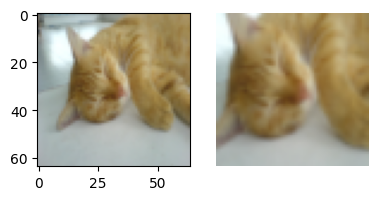

In [14]:
# function for cropping 

import cv2
import matplotlib.pyplot as plt

def apply_center_crop(X_4d, zoom_factor=0.7):
    """
    X_4d: (m, 64, 64, 3)
    zoom_factor: 0.75 means we take the middle 75% (48x48 pixels)
    """
    m, h, w, c = X_4d.shape
    # Calculate crop size (e.g., 48x48)
    crop_h, crop_w = int(h * zoom_factor), int(w * zoom_factor)
    
    # Calculate start points to center the crop
    start_h = (h - crop_h) // 2
    start_w = (w - crop_w) // 2
    
    X_cropped = np.zeros_like(X_4d)

    """Pre-allocation (np.zeros_like): You are creating the empty X_cropped array before the loop starts. 
    This is a "Basic Best Practice." If you tried to append images to a list inside the loop (e.g., list.append()), 
    it would be much slower because Python would have to re-allocate memory for the list every single time it grows."""
    
    for i in range(m):
        # 1. Slicing the middle
        img_crop = X_4d[i, start_h:start_h+crop_h, start_w:start_w+crop_w, :]
        # 2. Resizing back to 64x64
        X_cropped[i] = cv2.resize(img_crop, (w, h), interpolation=cv2.INTER_LINEAR)

        """You used cv2.resize(img_crop, (w, h)). A common mistake is passing (h, w), but OpenCV specifically expects (width, height). 
        Since your X_4d.shape gave you (m, h, w, c), passing (w, h) is exactly right"""
        
    return X_cropped


img_index = np.random.randint(0,train_set_x_orig.shape[0]) # randomly selecting an image and cropping it.
X_4d = train_set_x_orig[[img_index]]
img =X_4d[0]
cropped_imgs = apply_center_crop(X_4d, zoom_factor=0.7)
cropped_img= cropped_imgs[0]

plt.figure(figsize=(4, 2))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(cropped_img)

# plt.title(f"Pred: {y_hat[0,i]}, True: {test_set_y_orig[0, i]}")
plt.axis('off')
plt.tight_layout()
plt.show()
#

In [15]:
value_range = 25
shifts = np.random.randint(-value_range, value_range, size=(281, 1, 1, 1))
shifts.shape

(281, 1, 1, 1)

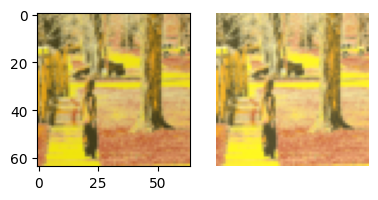

In [16]:
def apply_random_brightness(X_4d, value_range=50): # 50 is almost 20% of the 255 (maximum pixel value)
    # X_4d shape: (m, 64, 64, 3)
    m = X_4d.shape[0]
    
    # Generate random shifts for each image
    shifts = np.random.randint(-value_range, value_range, size=(m, 1, 1, 1))
    
    # Add shifts and clip to 0-255 range
    X_bright = np.clip(X_4d.astype(np.int16) + shifts, 0, 255)
    
    return X_bright.astype(np.uint8)

img_index = np.random.randint(0,train_set_x_orig.shape[0]) # randomly selecting an image and cropping it.
X_4d = train_set_x_orig[[img_index]]
img =X_4d[0]
bright_imgs = apply_random_brightness(X_4d, value_range =50)
bright_img= bright_imgs[0]

plt.figure(figsize=(4, 2))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(bright_img)

# plt.title(f"Pred: {y_hat[0,i]}, True: {test_set_y_orig[0, i]}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
# rotating the image

from scipy import ndimage


def augment_dataset(X_orig):
    
    # ROTATION to all the images.: --> List of 4 angles
    
    angle = np.random.randint(-80,+80)

        # Rotate the entire batch of images at once
        # reshape=False keeps the image at 64x64 so it doesn't grow
    X_rotated_batch = ndimage.rotate(X_orig, angle, axes=(1, 2), reshape=False)

    # CENTRE CROP TO THE ROTATED IMAGES

    zoom_factor = np.random.uniform(0.5, 1)
    X_rotated_cropped = apply_center_crop(X_rotated_batch, zoom_factor)

    # BRIGHTNESS RANDOMIZER 

    brightness_factor = 50 # almost 20% of 255 (maximum pixel value)
    X_rotated_cropped_bright = apply_random_brightness(X_rotated_cropped, value_range = brightness_factor)

    train_X_flatten = X_rotated_cropped_bright.reshape((train_set_x_orig.shape[0], -1))
    train_X_flatten = train_X_flatten.astype(float)
    train_X_flatten /= 255 

    # print('angle_rotated:', angle)
    # print('zoom factor', zoom_factor)
    # print('brightness:', brightness_factor)
    

    return train_X_flatten

# Run the augmentation
train_X_flatten = augment_dataset(train_set_x_orig)
print(f"New dataset size: {train_X_flatten.shape[1]} images") # Should be

New dataset size: 12288 images


In [18]:
# reshaping the test set 
# train_set_y_orig = train_set_y_orig.
# test_set_y_orig = test_set_y_orig.

# Flattening test X

# generalised version : # X_flatten = X_orig.reshape(X_orig.shape[0], -1).T  [ -1 computes 12288 for us]
test_X_flatten = test_set_x_orig.reshape((test_set_x_orig.shape[0], -1))
test_X_flatten = test_X_flatten.astype(float) # uint8 = unsigned = [0,255] will the range of pixel values.
test_X_flatten/= 255

print('Train set x shape',train_X_flatten.shape)
print('Train set y shape',train_set_y_orig.shape)
print('Test set x shape', test_X_flatten.shape)
print('Test set y shape', test_set_y_orig.shape)

Train set x shape (281, 12288)
Train set y shape (281, 1)
Test set x shape (50, 12288)
Test set y shape (50, 1)


(281, 64, 64, 3)


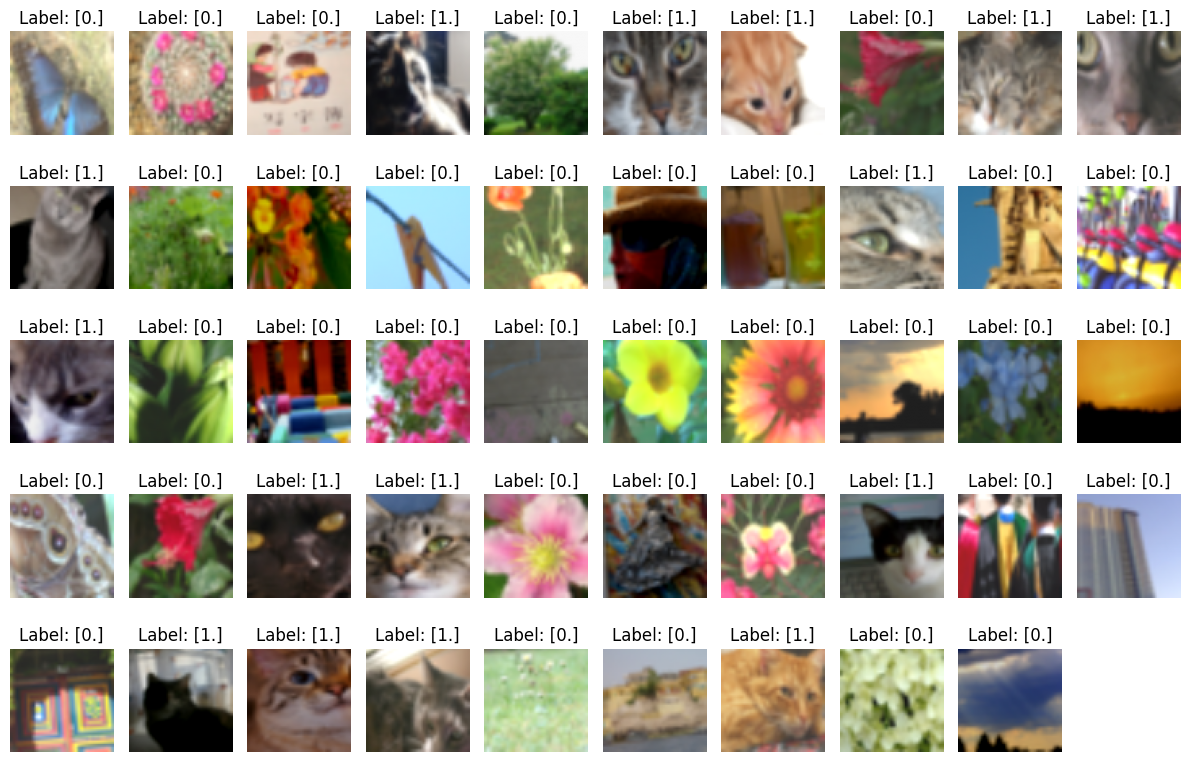

In [19]:
# seeing the images from 51 to 101 which has been randomly cropped, rotated, and brightness change

X = train_X_flatten.reshape(281, 64, 64, 3)
print(X.shape)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for i in range(51,100,1): # show first 12 images
    plt.subplot(5,10, i-50 )
    plt.imshow(X[i])
    plt.title(f"Label: {train_set_y_orig[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
#hyperparameters


dropout = 0.2
lr = 0.0001
layers_dims = [12288,64,16,1]


In [21]:
# conversting test set to torch tensor

test_X_flatten = torch.from_numpy(test_X_flatten).float() 
test_set_y_orig = torch.from_numpy(test_set_y_orig).float() 

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CatClassifier(nn.Module):
    def __init__(self, layers_dims):
        super().__init__()
        # Create a list to hold our layers
        layers = []
        
        # Loop through the dims to build a deep network automatically
        # Similar to your L-layer NumPy loop!
        for i in range(len(layers_dims) - 1):
            layers.append(nn.Linear(layers_dims[i], layers_dims[i+1]))
            
            # Use ReLU for hidden layers, but nothing for the last layer
            if i < len(layers_dims) - 2:
                layers.append(nn.ReLU())
        
        # Unpack the list into Sequential
        self.network = nn.Sequential(*layers)

    def forward(self, x, targets=None):
        logits = self.network(x)
        
        loss = None
        if targets is not None:
            # We use Logits (un-sigmoided values) for stability
            loss = F.binary_cross_entropy_with_logits(logits, targets)
            
        return logits, loss


model = CatClassifier(layers_dims)

In [23]:
import matplotlib.pyplot as plt

# 1. Initialize lists to store metrics
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
steps = []

In [24]:
# @title
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr)


for i in range(500): # increase number of steps for good results...
# sample a batch of data

    model.train()
    train_X_flatten = augment_dataset(train_set_x_orig) 
    train_X_flatten = torch.from_numpy(train_X_flatten).float()  
    yb = train_set_y_orig
    yb = torch.from_numpy(yb).float()
    
    
    # evaluate the training loss
    logits, loss = model(train_X_flatten, targets = yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if i%10 ==0:
        model.eval()
        # Method A: Use the Logit threshold (Faster
        predictions = (logits > 0).float()
    
        # Method B: Apply Sigmoid manually just for visualization
        # probs = torch.sigmoid(logits)
        # predictions = (probs > 0.5).float()

        # Calculate Training Accuracy
        correct = (predictions == yb).sum().item()
        train_accuracy = correct / yb.size(0)
        print(f"Iteration {i:5}: Train_Loss: {loss.item():.6f} | Train_Accuracy: {train_accuracy:.2%}")



        with torch.no_grad():
        
            # Calculate Testing Accuracy
            test_logits, test_loss = model(test_X_flatten, targets = test_set_y_orig)

            # 2. Append to lists (use .item() to keep memory clean!)
            train_losses.append(loss.item())
            test_losses.append(test_loss.item())
            steps.append(i)
            
            predictions = (test_logits > 0).float()
            correct = (predictions == test_set_y_orig  ).sum().item()
            test_accuracy = correct / test_set_y_orig .size(0)
            print(f"Iteration {i:5}: Test_Loss: {test_loss.item():.6f} | Test_Accuracy: {test_accuracy:.2%}")
          
            train_accuracies.append(train_accuracy)
            test_accuracies.append(test_accuracy)




Iteration     0: Train_Loss: 0.692363 | Train_Accuracy: 48.75%
Iteration     0: Test_Loss: 0.651588 | Test_Accuracy: 66.00%
Iteration    10: Train_Loss: 0.679867 | Train_Accuracy: 56.58%
Iteration    10: Test_Loss: 0.672571 | Test_Accuracy: 60.00%
Iteration    20: Train_Loss: 0.671734 | Train_Accuracy: 62.28%
Iteration    20: Test_Loss: 0.640427 | Test_Accuracy: 72.00%
Iteration    30: Train_Loss: 0.668412 | Train_Accuracy: 60.14%
Iteration    30: Test_Loss: 0.629168 | Test_Accuracy: 70.00%
Iteration    40: Train_Loss: 0.635738 | Train_Accuracy: 66.19%
Iteration    40: Test_Loss: 0.586854 | Test_Accuracy: 76.00%
Iteration    50: Train_Loss: 0.626674 | Train_Accuracy: 65.84%
Iteration    50: Test_Loss: 0.560295 | Test_Accuracy: 86.00%
Iteration    60: Train_Loss: 0.610580 | Train_Accuracy: 70.82%
Iteration    60: Test_Loss: 0.556138 | Test_Accuracy: 84.00%
Iteration    70: Train_Loss: 0.625104 | Train_Accuracy: 67.62%
Iteration    70: Test_Loss: 0.546058 | Test_Accuracy: 84.00%
Iteratio

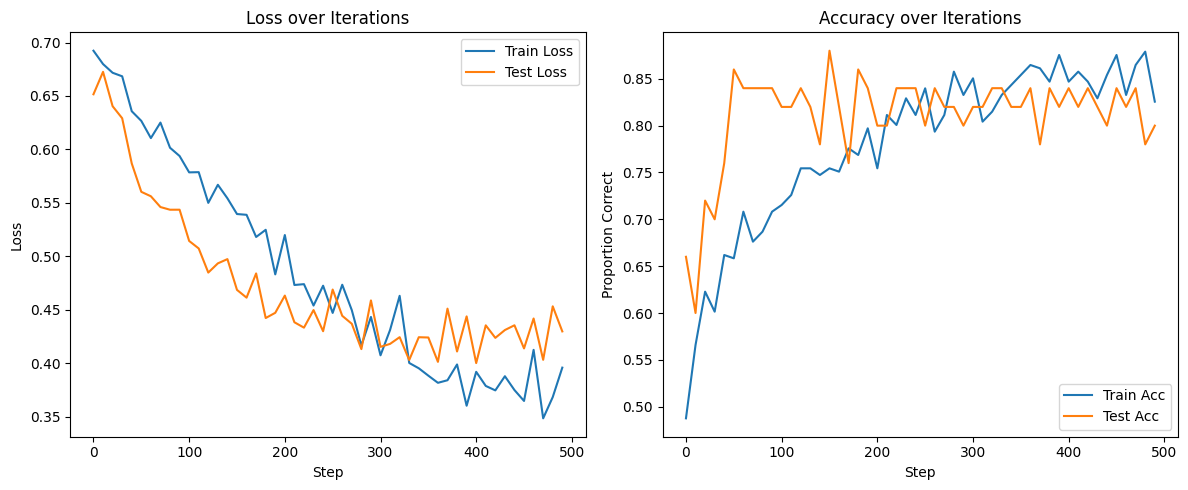

In [25]:
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(steps, train_losses, label='Train Loss')
plt.plot(steps, test_losses, label='Test Loss')
plt.title('Loss over Iterations')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(steps, train_accuracies, label='Train Acc')
plt.plot(steps, test_accuracies, label='Test Acc')
plt.title('Accuracy over Iterations')
plt.xlabel('Step')
plt.ylabel('Proportion Correct')
plt.legend()

plt.tight_layout()
plt.show()